# **Drug Drug Interaction Analysis**

## **Inits**

In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [9]:
path = "C:\\Users\\User\\Desktop\\Dataset\\Drug_Drug_Interation.csv"

In [10]:
df = pd.read_csv(path)
df.head(20)

,Drug 1,Drug 2,Interaction Description
0,Trioxsalen,Verteporfin,Trioxsalen may increase the photosensitizing a...
1,Aminolevulinic acid,Verteporfin,Aminolevulinic acid may increase the photosens...
2,Titanium dioxide,Verteporfin,Titanium dioxide may increase the photosensiti...
3,Tiaprofenic acid,Verteporfin,Tiaprofenic acid may increase the photosensiti...
4,Cyamemazine,Verteporfin,Cyamemazine may increase the photosensitizing ...
5,Temoporfin,Verteporfin,Temoporfin may increase the photosensitizing a...
6,Methoxsalen,Verteporfin,Methoxsalen may increase the photosensitizing ...
7,Hexaminolevulinate,Verteporfin,Hexaminolevulinate may increase the photosensi...
8,Benzophenone,Verteporfin,Benzophenone may increase the photosensitizing...
9,Riboflavin,Verteporfin,Riboflavin may increase the photosensitizing a...


## **Statistical Analysis & Visualization**

In [11]:
df

,Drug 1,Drug 2,Interaction Description
0,Trioxsalen,Verteporfin,Trioxsalen may increase the photosensitizing a...
1,Aminolevulinic acid,Verteporfin,Aminolevulinic acid may increase the photosens...
2,Titanium dioxide,Verteporfin,Titanium dioxide may increase the photosensiti...
3,Tiaprofenic acid,Verteporfin,Tiaprofenic acid may increase the photosensiti...
4,Cyamemazine,Verteporfin,Cyamemazine may increase the photosensitizing ...
...,...,...,...
191536,Ascorbic acid,Deferoxamine,The risk or severity of adverse effects can be...
191537,Tenofovir disoproxil,Cidofovir,Tenofovir disoproxil may decrease the excretio...
191538,Tenofovir disoproxil,Ganciclovir,The serum concentration of Ganciclovir can be ...
191539,Tenofovir disoproxil,Valganciclovir,The serum concentration of Valganciclovir can ...


In [12]:
# Drug1 → source node
# Drug2 → target node
# interaction → edge

G = nx.from_pandas_edgelist(
    df,
    source='Drug 1',
    target='Drug 2',
    edge_attr='Interaction Description',
    create_using=nx.Graph()
)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 1701
Number of edges: 191135


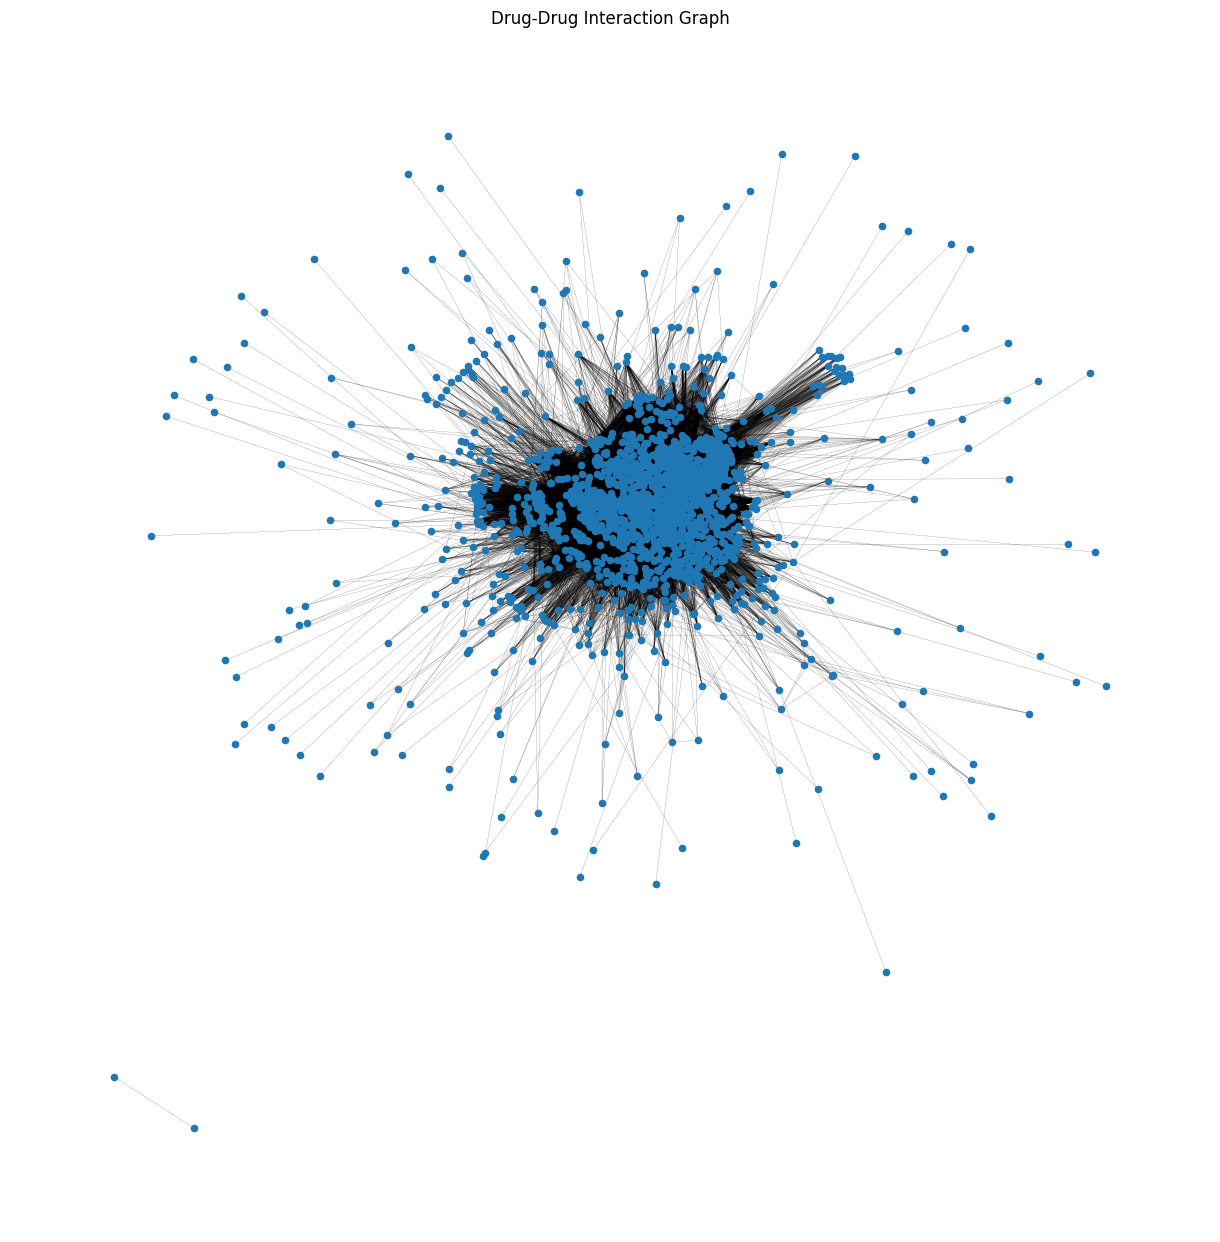

In [13]:
# Let's have some stupid visualization
# This shows all the nodes and relations, irrespective of what they are or really mean

plt.figure(figsize=(12, 12))

nx.draw(
    G,
    with_labels=False,
    node_size=20,
    width=0.1
)

plt.title("Drug-Drug Interaction Graph")
plt.show()

According to the previous figure
1) We can see 2 different connected graphs. So, the number of connected graphs should be 2.
2) We expect the larger connected graph to have  several hubs and each with very great number of nodes
3) We expect the average degree of graph to be great
4) We expect the size of the largest graph to be great

In [14]:
# --- Graph Statistics ---

print("\n===== Graph Statistics =====")

# 1) Basic counts
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())


===== Graph Statistics =====
Number of nodes: 1701
Number of edges: 191135


In [15]:
# 2) Degree statistics
degrees = dict(G.degree())
max_degree_drug = max(degrees, key=degrees.get)
min_degree_drug = min(degrees, key=degrees.get)

print("\n--- Degree Statistics ---")

# Average degree = (sum of degrees of all nodes) / (number of nodes)
# In an undirected graph, degree = number of connections a node has
average_degree = sum(degrees.values()) / len(degrees)
print("Average degree:", average_degree)

print(f"Highest degree node: {max_degree_drug} (degree = {degrees[max_degree_drug]})")
print(f"Lowest degree node: {min_degree_drug} (degree = {degrees[min_degree_drug]})")


--- Degree Statistics ---
Average degree: 224.73251028806584
Highest degree node: Phenobarbital (degree = 912)
Lowest degree node: Trioxsalen (degree = 1)


In [16]:
# 3) Connected components

# connected_components = groups of nodes where every node is reachable from any other node in the same group.
# If two nodes have no path between them, they belong to different connected components.
# This helps identify isolated sub-networks within the graph.
components = list(nx.connected_components(G))

# largest_component = the connected component with the highest number of nodes.
# In network analysis, the largest component usually represents the main interaction cluster.
largest_component = max(components, key=len)

print("\n--- Connectivity ---")

# Number of disconnected subgraphs in the entire network.
# Each component represents an isolated drug interaction region.
print("Number of connected components:", len(components))

print("According to the visualization that we have done earlier, 2 different connected components are expected")
print("")

# Size of the largest connected component (number of nodes inside it).
# This shows how many drugs belong to the main, most interconnected part of the network.
print("Size of largest component:", len(largest_component))


--- Connectivity ---
Number of connected components: 2
According to the visualization that we have done earlier, 2 different connected components are expected

Size of largest component: 1699


In [17]:
# 4) Centrality metrics

# Degree centrality:
# Measures how many direct connections (edges) a node has.
# A higher value means the drug interacts with many others and is highly connected.
degree_centrality = nx.degree_centrality(G)

# Betweenness centrality:
# Measures how often a node appears on the shortest paths between other nodes.
# Nodes with high betweenness act as "bridges" or intermediaries in the network.
# In drug interaction networks, these nodes often represent drugs that connect otherwise separate groups.
betweenness = nx.betweenness_centrality(G)

# Closeness centrality:
# Measures how close a node is to all other nodes in terms of shortest path distances.
# A node with high closeness can quickly reach the rest of the network.
# These nodes often represent influential drugs with fast access to many interaction pathways.
closeness = nx.closeness_centrality(G)

# Identify the node with the highest score in each metric.
top_degree = max(degree_centrality, key=degree_centrality.get)
top_betweenness = max(betweenness, key=betweenness.get)
top_closeness = max(closeness, key=closeness.get)

print("\n--- Centrality ---")

# Degree centrality highlights nodes that are highly connected.
print(f"Top degree-centrality node: {top_degree} ({degree_centrality[top_degree]:.4f})")

# Betweenness centrality highlights nodes that control communication or flow in the network.
print(f"Top betweenness-centrality node: {top_betweenness} ({betweenness[top_betweenness]:.4f})")

# Closeness centrality highlights nodes that can reach other nodes quickly.
print(f"Top closeness-centrality node: {top_closeness} ({closeness[top_closeness]:.4f})")


--- Centrality ---
Top degree-centrality node: Phenobarbital (0.5365)
Top betweenness-centrality node: Picosulfuric acid (0.0273)
Top closeness-centrality node: Phenobarbital (0.6682)


In [18]:
# 5) Density

print("\n--- Density ---")

# Graph density:
# Density measures how many edges exist in the graph compared to the maximum number of possible edges.
# For an undirected graph with N nodes, the maximum possible edges is: N*(N-1)/2.
# Density ranges from 0 to 1:
#   - 0 means no nodes are connected.
#   - 1 means every node is connected to every other node (a fully connected network).
# In drug–drug interaction networks, density shows how interconnected the drug set is overall.
print("Graph density:", nx.density(G))



--- Density ---
Graph density: 0.13219559428709757


In [19]:
# 6) Clustering

# Clustering coefficient:
# Measures how strongly a node's neighbors are connected to each other.
# In other words, it checks whether the neighbors of a node also form connections among themselves.
# A high clustering value means the node belongs to a tightly connected local group.

# Compute clustering coefficient for every node in the graph.
clustering = nx.clustering(G)

# Average clustering coefficient:
# Represents the overall tendency of the network to form local clusters or communities.
# Values range from 0 to 1:
#   - 0 means neighbors are rarely connected.
#   - 1 means neighbors are fully interconnected.
# In drug interaction networks, high clustering may indicate groups of drugs
# that commonly interact with one another.
avg_cluster = sum(clustering.values()) / len(clustering)

print("\n--- Clustering ---")
print("Average clustering coefficient:", avg_cluster)



--- Clustering ---
Average clustering coefficient: 0.545763786818543


In [20]:
# 7) Triangle count (local motifs)

# Triangle:
# A triangle is a group of three nodes where each node is connected to the other two.
# In graph theory, triangles are considered small local structures called "motifs".
# They often indicate tightly related or highly interconnected groups.

# Count the number of triangles associated with each node.
# Each triangle is counted once for every participating node.
triangles = nx.triangles(G)

# Since every triangle is counted three times (once per node),
# divide the total by 3 to obtain the actual number of unique triangles.
total_triangles = sum(triangles.values()) / 3

print("\n--- Motifs ---")

# In drug interaction networks, triangles may represent:
#   - groups of drugs with mutual interactions,
#   - shared pharmacological mechanisms,
#   - or highly interconnected therapeutic clusters.
print("Total triangles in graph:", int(total_triangles))



--- Motifs ---
Total triangles in graph: 12425984


## **Let's Investigate the inner connections among the 50 greatest hubs**


--- Subgraph Statistics (Top 50 hubs) ---
Number of nodes: 50
Number of edges: 1207
Average degree: 48.28
Fully connected graph: False


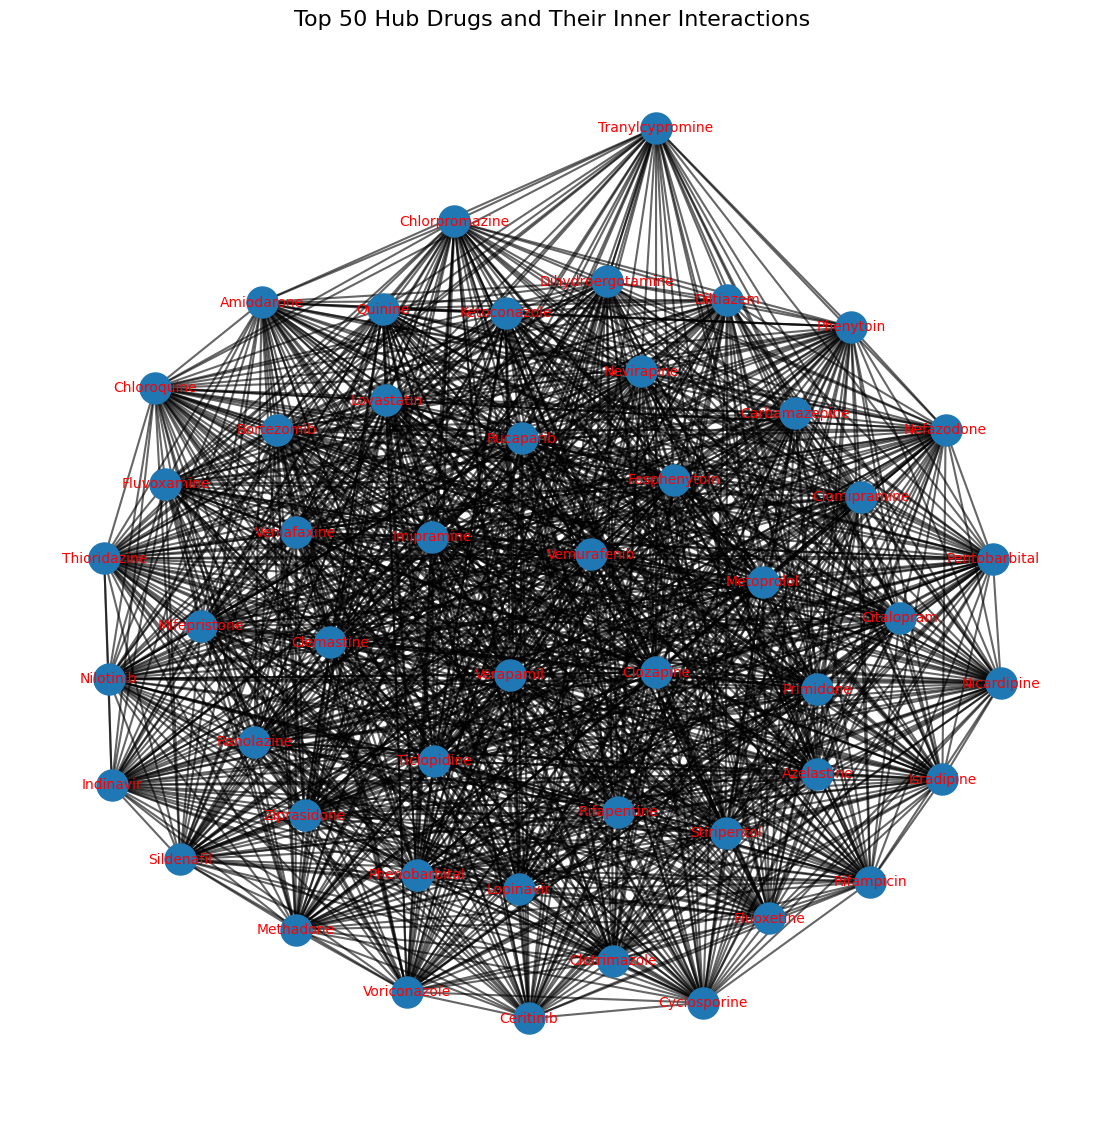

In [21]:
# ==========================================
# Step 1: Calculate degree of each drug
# Degree = number of interaction edges connected to a drug
# ==========================================

degrees = dict(G.degree())


# ==========================================
# Step 2: Find top 50 hub drugs
# These are the drugs with the highest number
# of interactions in the whole network
# ==========================================

top_50_drugs = sorted(
    degrees,
    key=degrees.get,
    reverse=True
)[:50]


# ==========================================
# Step 3: Create a subgraph using ONLY
# the top 50 hub drugs
# The subgraph keeps interactions that exist
# between these 50 drugs
# ==========================================

hub_subgraph = G.subgraph(top_50_drugs)


# ==========================================
# Step 4: Compute statistics of this subgraph
# ==========================================

# Average degree of nodes in the subgraph
avg_degree = sum(dict(hub_subgraph.degree()).values()) / hub_subgraph.number_of_nodes()

# Check if the graph is fully connected
# Fully connected (complete graph) means every node connects to every other node
n = hub_subgraph.number_of_nodes()
max_possible_edges = n * (n - 1) / 2
is_fully_connected = hub_subgraph.number_of_edges() == max_possible_edges


print("\n--- Subgraph Statistics (Top 50 hubs) ---")
print("Number of nodes:", hub_subgraph.number_of_nodes())
print("Number of edges:", hub_subgraph.number_of_edges())
print("Average degree:", round(avg_degree, 2))
print("Fully connected graph:", is_fully_connected)


# ==========================================
# Step 5: Create figure
# ==========================================

plt.figure(figsize=(14, 14))


# ==========================================
# Step 6: Generate graph layout
# spring_layout positions nodes so that
# connected nodes appear closer together
# ==========================================

pos = nx.spring_layout(
    hub_subgraph,
    seed=42
)


# ==========================================
# Step 7: Draw nodes
# ==========================================

nx.draw_networkx_nodes(
    hub_subgraph,
    pos,
    node_size=500
)


# ==========================================
# Step 8: Draw edges (drug interactions)
# ==========================================

nx.draw_networkx_edges(
    hub_subgraph,
    pos,
    width=1.5,
    alpha=0.6
)


# ==========================================
# Step 9: Draw node labels (drug names)
# Smaller font because the graph has many nodes
# ==========================================

nx.draw_networkx_labels(
    hub_subgraph,
    pos,
    font_size=10,
    font_color = "red"
)


# ==========================================
# Step 10: Add title
# ==========================================

plt.title(
    "Top 50 Hub Drugs and Their Inner Interactions",
    fontsize=16
)


# ==========================================
# Step 11: Remove axis
# ==========================================

plt.axis('off')


# ==========================================
# Step 12: Show graph
# ==========================================

plt.show()


## **Increase in adverse effects (example)**

In [22]:
adverse_effects_interactions_df = df[df['Interaction Description'].str.contains(
    'The risk or severity of adverse effects can be increased when',
    case=False,
    na=False
)]


# !!! ATTENTION !!! => This is a simple analysis just based on NLP of description (if it contains some words)
#                      This is NOT an idea way to do it. Yet, we wanted to do some sort of small analysis. Therefore, justifiable


In [23]:
adverse_effects_interactions_df

,Drug 1,Drug 2,Interaction Description
12,Paclitaxel,Verteporfin,The risk or severity of adverse effects can be...
13,Docetaxel,Verteporfin,The risk or severity of adverse effects can be...
14,Cabazitaxel,Verteporfin,The risk or severity of adverse effects can be...
21,Sulpiride,Digoxin,The risk or severity of adverse effects can be...
39,Etacrynic acid,Digoxin,The risk or severity of adverse effects can be...
...,...,...,...
191524,Valganciclovir,Emtricitabine,The risk or severity of adverse effects can be...
191525,Metoclopramide,Trimetazidine,The risk or severity of adverse effects can be...
191532,Ganciclovir,Entecavir,The risk or severity of adverse effects can be...
191533,Valganciclovir,Entecavir,The risk or severity of adverse effects can be...


In [24]:
import networkx as nx
import matplotlib.pyplot as plt

# Adverse effects graph
G = nx.from_pandas_edgelist(
    adverse_effects_interactions_df,
    source='Drug 1',
    target='Drug 2'
)

# Nodes and Edges
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)


Number of nodes: 1306
Number of edges: 60722


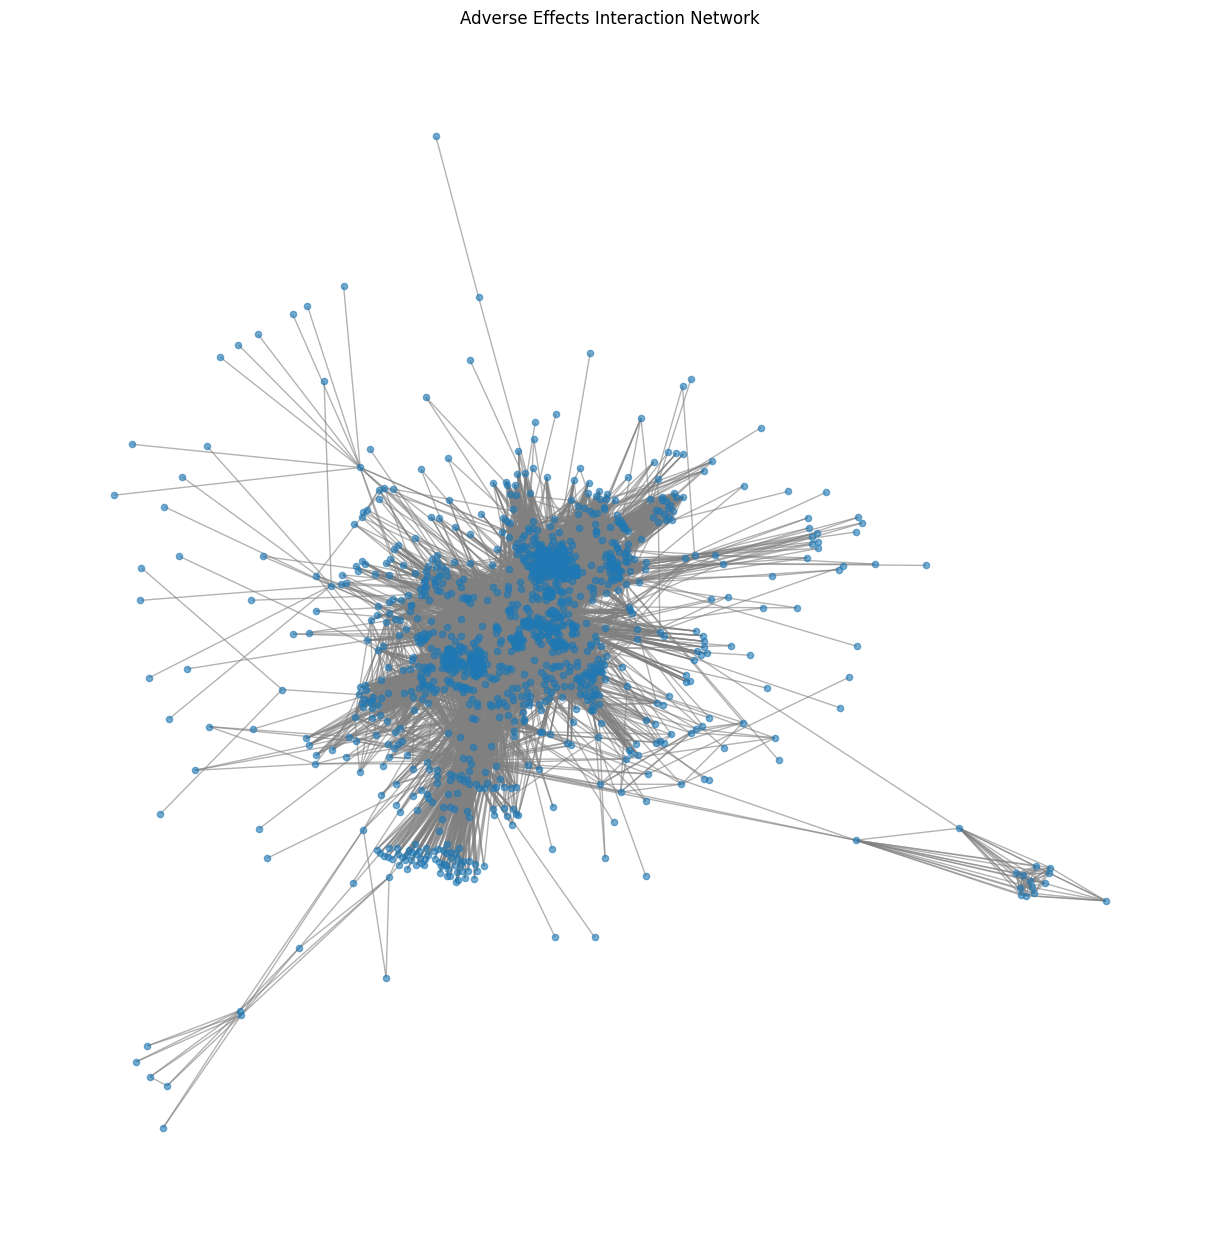

In [25]:
# Graph visualization
plt.figure(figsize=(12, 12))

pos = nx.spring_layout(G, k=0.15)

nx.draw(
    G,
    pos,
    node_size=20,
    edge_color='gray',
    alpha=0.6,
    with_labels=False
)

plt.title("Adverse Effects Interaction Network")
plt.show()

# expected to be slightly less congested

In [26]:
import networkx as nx
import numpy as np

print("Basic Network Statistics")
print("------------------------")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Density:", nx.density(G))

# Degree statistics
degrees = [d for n, d in G.degree()]
print("\nDegree Statistics")
print("-----------------")
print("Average degree:", np.mean(degrees))
print("Max degree:", np.max(degrees))
print("Min degree:", np.min(degrees))
print("Std degree:", np.std(degrees))

# Connected components
components = list(nx.connected_components(G))
print("\nConnectivity")
print("------------")
print("Number of connected components:", len(components))

largest_cc = max(components, key=len)
G_lcc = G.subgraph(largest_cc)

print("Size of largest connected component:", len(G_lcc.nodes()))

# Path statistics 
print("\nPath Statistics (Largest Component)")
print("-----------------------------------")
print("Average shortest path length:", nx.average_shortest_path_length(G_lcc))
print("Diameter:", nx.diameter(G_lcc))

# Clustering
print("\nClustering")
print("----------")
print("Average clustering coefficient:", nx.average_clustering(G))
print("Transitivity:", nx.transitivity(G))

# Centrality summaries
degree_centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)

print("\nCentrality (Top values)")
print("-----------------------")
print("Max degree centrality:", max(degree_centrality.values()))
print("Max betweenness centrality:", max(betweenness.values()))
print("Max closeness centrality:", max(closeness.values()))


Basic Network Statistics
------------------------
Number of nodes: 1306
Number of edges: 60722
Density: 0.07125615344446205

Degree Statistics
-----------------
Average degree: 92.98928024502297
Max degree: 414
Min degree: 1
Std degree: 98.07140978124268

Connectivity
------------
Number of connected components: 2
Size of largest connected component: 1302

Path Statistics (Largest Component)
-----------------------------------
Average shortest path length: 2.5413311986171574
Diameter: 7

Clustering
----------
Average clustering coefficient: 0.5471006979621211
Transitivity: 0.6579031019536962

Centrality (Top values)
-----------------------
Max degree centrality: 0.31724137931034485
Max betweenness centrality: 0.10770465119351584
Max closeness centrality: 0.5505145418235986


## **Hub Detection**

In [27]:
import numpy as np
import pandas as pd

# 1) Calculate the degree of each node
# Convert degree view to dictionary and then to a sorted pandas Series
node_degrees = dict(G.degree())
sorted_degrees = pd.Series(node_degrees, name="degree").sort_values(ascending=False)


# 2) Define different hub identification criteria
# Criterion A: Top-k approach (fixed number of nodes)
top_k_count = 20
top_k_hubs = sorted_degrees.head(top_k_count)


# Criterion B: Percentage-based threshold (top 1% of nodes)
top_percent_ratio = 0.01 
percentile_threshold = sorted_degrees.quantile(1 - top_percent_ratio)
percentile_hubs = sorted_degrees[sorted_degrees >= percentile_threshold]


# Criterion C: Statistical Z-score approach (mean + 2 standard deviations)
mean_deg, std_deg = sorted_degrees.mean(), sorted_degrees.std()
z_score_threshold = mean_deg + 2 * std_deg
statistical_hubs = sorted_degrees[sorted_degrees >= z_score_threshold]


# 3) Print summary of network statistics and hub detection
print("Hub Analysis Summary")
print("-" * 30)
print(f"Total Nodes: {G.number_of_nodes():,}")
print(f"Total Edges: {G.number_of_edges():,}")
print(f"Top-{top_k_count} Hubs identified.")
print(f"Top {top_percent_ratio*100:.0f}% Hubs (degree >= {percentile_threshold:.0f}): {len(percentile_hubs)} nodes.")
print(f"Z-score Hubs (degree >= mean+2std = {z_score_threshold:.2f}): {len(statistical_hubs)} nodes.")


# 4) Prepare a DataFrame for the results (using the top 1% hubs as the primary result)
hub_df = percentile_hubs.reset_index()
hub_df.columns = ["drug_name", "interaction_count"]


# Display the top 30 most connected drugs
hub_df.head(30)


Hub Analysis Summary
------------------------------
Total Nodes: 1,306
Total Edges: 60,722
Top-20 Hubs identified.
Top 1% Hubs (degree >= 344): 14 nodes.
Z-score Hubs (degree >= mean+2std = 289.21): 48 nodes.


,drug_name,interaction_count
0,Remifentanil,414
1,Olopatadine,390
2,Pipamperone,383
3,Morphine,379
4,Tolcapone,376
5,Sufentanil,374
6,Reserpine,364
7,Clozapine,359
8,Fluticasone propionate,353
9,Meperidine,353


## **Bridge / Bottleneck Detection (Betweenness Centrality)**

Bottleneck / Bridge Analysis (Betweenness)
------------------------------------------
Original graph: nodes=1,306, edges=60,722
LCC graph:      nodes=1,302, edges=60,719

Computing EXACT betweenness centrality (may still take time)...

Mode: exact
Top-30 bottlenecks (highest betweenness):


,drug_name,betweenness
0,Paclitaxel,0.108368
1,Clozapine,0.055520
2,Docetaxel,0.035068
3,Atorvastatin,0.028628
4,Ethanol,0.028242
5,Olopatadine,0.027286
6,Bromocriptine,0.027113
7,Cabazitaxel,0.024464
8,Mecamylamine,0.023448
9,Fluticasone propionate,0.022727



Visualization subgraph: nodes=1,134, edges=58,522


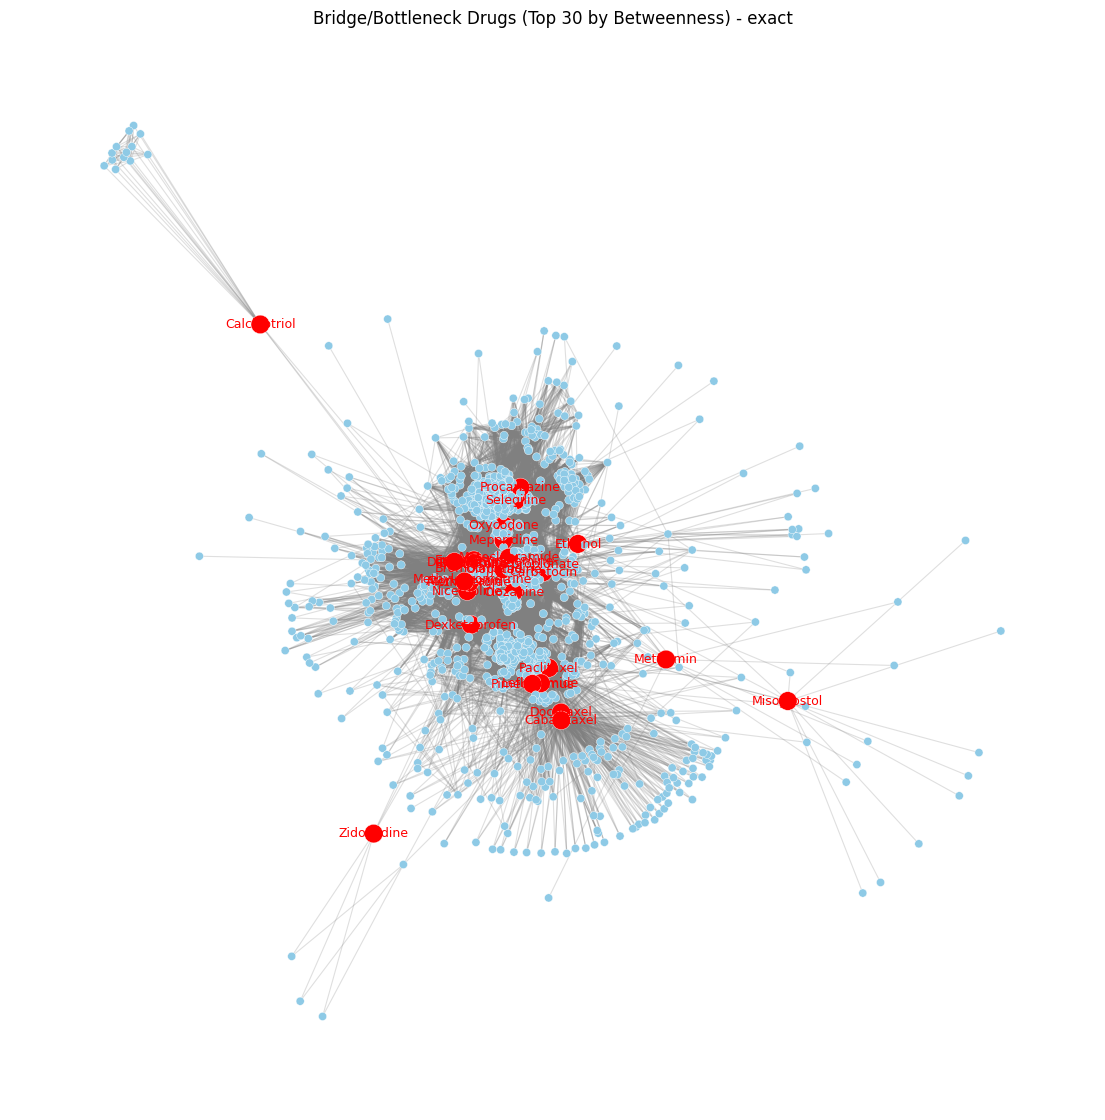

In [28]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 0) Basic setup ---
TOP_N = 30                 # how many bottlenecks to report
MAX_EXACT_NODES = 8000     # if LCC is larger than this, use approximation
K_SAMPLES = 2000           # number of sample nodes for approximate betweenness (tune for speed/accuracy)
RANDOM_SEED = 42



# --- 1) Work on the Largest Connected Component (LCC) ---
components = list(nx.connected_components(G))
lcc_nodes = max(components, key=len)
G_lcc = G.subgraph(lcc_nodes).copy()

print("Bottleneck / Bridge Analysis (Betweenness)")
print("------------------------------------------")
print(f"Original graph: nodes={G.number_of_nodes():,}, edges={G.number_of_edges():,}")
print(f"LCC graph:      nodes={G_lcc.number_of_nodes():,}, edges={G_lcc.number_of_edges():,}")



# --- 2) Compute betweenness centrality (exact or approximate) ---
n_lcc = G_lcc.number_of_nodes()

if n_lcc <= MAX_EXACT_NODES:
    print("\nComputing EXACT betweenness centrality (may still take time)...")
    bet = nx.betweenness_centrality(G_lcc, normalized=True)
    bet_mode = "exact"
else:
    print("\nComputing APPROXIMATE betweenness centrality (faster)...")
    rng = np.random.default_rng(RANDOM_SEED)
    k = min(K_SAMPLES, n_lcc)
    sample_nodes = rng.choice(list(G_lcc.nodes()), size=k, replace=False).tolist()
    bet = nx.betweenness_centrality(G_lcc, normalized=True, k=k, seed=RANDOM_SEED)
    bet_mode = f"approx(k={k})"



# --- 3) Create a ranked table of bottlenecks ---
bet_s = pd.Series(bet, name="betweenness").sort_values(ascending=False)
bottlenecks_df = bet_s.head(TOP_N).reset_index()
bottlenecks_df.columns = ["drug_name", "betweenness"]

print(f"\nMode: {bet_mode}")
print(f"Top-{TOP_N} bottlenecks (highest betweenness):")
display(bottlenecks_df)



# --- 4) Optional: build a small subgraph for visualization ---
# Include top bottlenecks + their immediate neighbors to see "bridge" structure
top_nodes = bottlenecks_df["drug_name"].tolist()
neighbors = set()
for node in top_nodes:
    neighbors.update(G_lcc.neighbors(node))

viz_nodes = set(top_nodes) | neighbors
G_viz = G_lcc.subgraph(viz_nodes).copy()

print(f"\nVisualization subgraph: nodes={G_viz.number_of_nodes():,}, edges={G_viz.number_of_edges():,}")



# --- 5) Draw the visualization subgraph ---
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G_viz, seed=RANDOM_SEED, k=0.25)

# Draw edges
nx.draw_networkx_edges(G_viz, pos, alpha=0.25, width=0.8, edge_color="gray")

# Draw nodes: bottlenecks in red, others in light blue
node_colors = ["red" if n in top_nodes else "#8ecae6" for n in G_viz.nodes()]
node_sizes = [180 if n in top_nodes else 35 for n in G_viz.nodes()]
nx.draw_networkx_nodes(G_viz, pos, node_color=node_colors, node_size=node_sizes, linewidths=0.3, edgecolors="white")

# Label only the bottlenecks
nx.draw_networkx_labels(G_viz, pos, labels={n: n for n in top_nodes}, font_size=9, font_color="red")

plt.title(f"Bridge/Bottleneck Drugs (Top {TOP_N} by Betweenness) - {bet_mode}")
plt.axis("off")
plt.show()


## **Community Detection ((Greedy Modularity))**

Community Detection (Greedy Modularity)
-------------------------------------------------------------
LCC nodes: 1,302
LCC edges: 60,719

Running greedy modularity community detection...
Detected 8 communities.

Sample community assignments:


,drug_name,community_id
0,Abemaciclib,0
1,Medrogestone,0
2,Proguanil,0
3,Propofol,0
4,Bretylium,0



Top 10 community sizes:
community_id
0    647
1    370
2    220
3     29
4     15
5     10
6      9
7      2
Name: count, dtype: int64


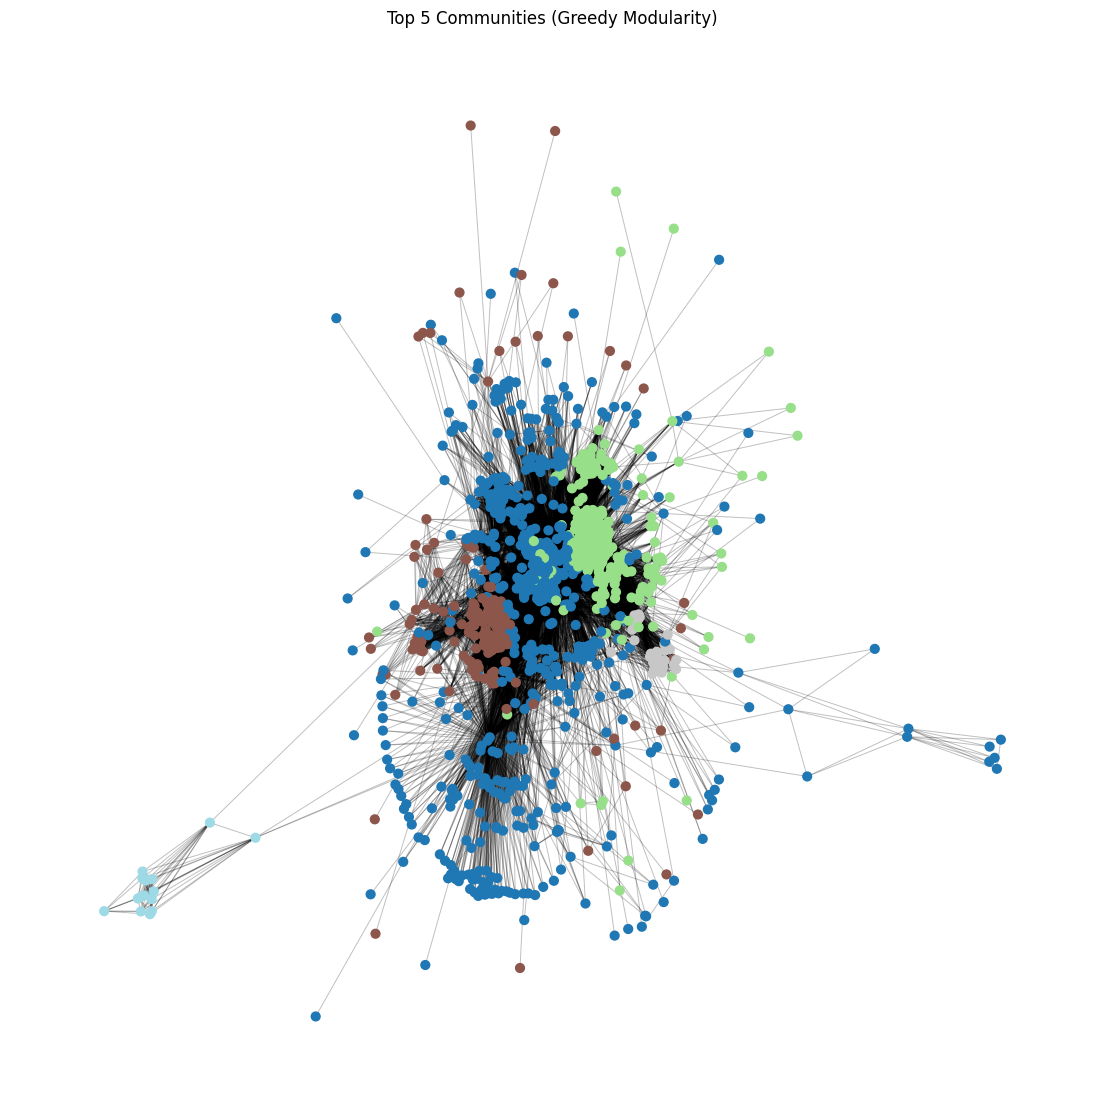

In [29]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 1) Largest Connected Component ----------
components = list(nx.connected_components(G))
lcc_nodes = max(components, key=len)
G_lcc = G.subgraph(lcc_nodes).copy()

print("Community Detection (Greedy Modularity)")
print("-------------------------------------------------------------")
print(f"LCC nodes: {G_lcc.number_of_nodes():,}")
print(f"LCC edges: {G_lcc.number_of_edges():,}")

# ---------- 2) Run Greedy Modularity Communities ----------
print("\nRunning greedy modularity community detection...")
communities = list(nx.algorithms.community.greedy_modularity_communities(G_lcc))

print(f"Detected {len(communities)} communities.")

# ---------- 3) Build dataframe ----------
rows = []
for cid, comm in enumerate(communities):
    for node in comm:
        rows.append([node, cid])

community_df = pd.DataFrame(rows, columns=["drug_name", "community_id"])
print("\nSample community assignments:")
display(community_df.head())

# ---------- 4) Community sizes ----------
sizes = community_df["community_id"].value_counts().sort_values(ascending=False)
print("\nTop 10 community sizes:")
print(sizes.head(10))

# ---------- 5) Visualization of top 5 communities ----------
top_5 = sizes.head(5).index.tolist()
viz_nodes = community_df[community_df["community_id"].isin(top_5)]["drug_name"]
G_viz = G_lcc.subgraph(viz_nodes).copy()

plt.figure(figsize=(14,14))
pos = nx.spring_layout(G_viz, seed=42, k=0.35)

node_colors = [community_df.loc[community_df["drug_name"] == n, "community_id"].values[0] for n in G_viz.nodes()]

nx.draw_networkx_nodes(G_viz, pos, node_color=node_colors, cmap="tab20", node_size=40)
nx.draw_networkx_edges(G_viz, pos, alpha=0.25, width=0.7)

plt.title("Top 5 Communities (Greedy Modularity)")
plt.axis("off")
plt.show()

## **Community Detection (Louvain Method)**

In [30]:
!pip install python-louvain


In [31]:
from community import community_louvain


Community Detection (Louvain Method)
------------------------------------
LCC nodes: 1,302
LCC edges: 60,719

Running Louvain… this may take a few seconds.

Top 10 community sizes:
community
5    377
1    285
6    259
4    245
0     71
7     48
3     15
2      2
Name: count, dtype: int64

Community assignments sample:


,drug_name,community_id
0,Paclitaxel,5
1,Verteporfin,5
2,Docetaxel,5
3,Cabazitaxel,5
4,Sulpiride,1



Visualization subgraph:
nodes=1,237, edges=58,415


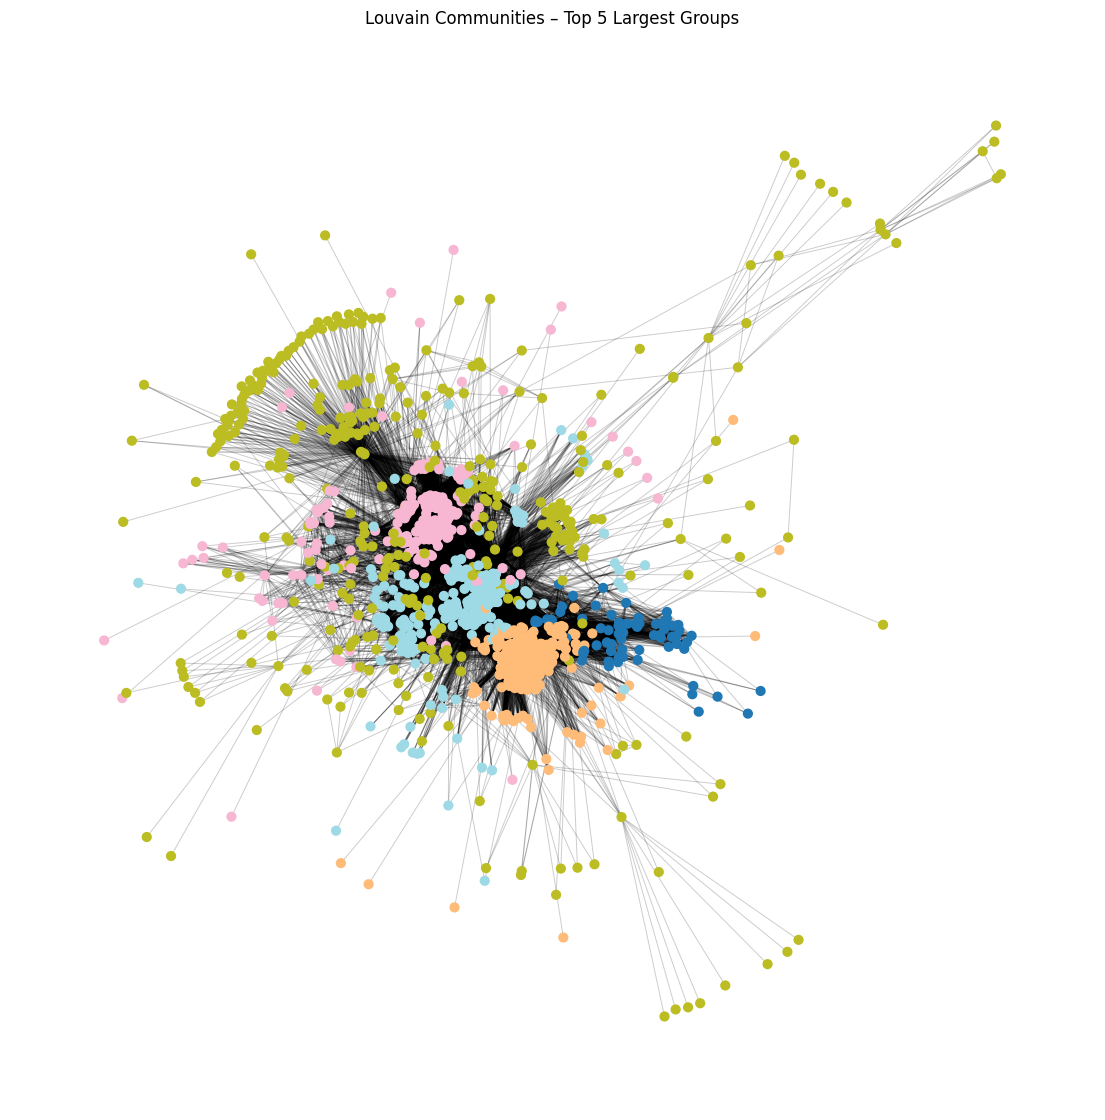

In [32]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Install if not already available (uncomment if needed)
# !pip install python-louvain

from community import community_louvain

# --- 1) Largest Connected Component ---
components = list(nx.connected_components(G))
lcc_nodes = max(components, key=len)
G_lcc = G.subgraph(lcc_nodes).copy()

print("Community Detection (Louvain Method)")
print("------------------------------------")
print(f"LCC nodes: {G_lcc.number_of_nodes():,}")
print(f"LCC edges: {G_lcc.number_of_edges():,}")

# --- 2) Run Louvain community detection ---
print("\nRunning Louvain… this may take a few seconds.")
partition = community_louvain.best_partition(G_lcc, random_state=42)

# partition: dict {node: community_id}
comm_series = pd.Series(partition, name="community")

# --- 3) Count community sizes ---
comm_counts = comm_series.value_counts().sort_values(ascending=False)
print("\nTop 10 community sizes:")
print(comm_counts.head(10))

# --- 4) Build a dataframe of drugs & their communities ---
community_df = comm_series.reset_index()
community_df.columns = ["drug_name", "community_id"]

print("\nCommunity assignments sample:")
display(community_df.head())

# --- 5) Visualization: show only the 5 largest communities ---
top_comms = comm_counts.head(5).index.tolist()
viz_nodes = [n for n, c in partition.items() if c in top_comms]
G_viz = G_lcc.subgraph(viz_nodes).copy()

print("\nVisualization subgraph:")
print(f"nodes={G_viz.number_of_nodes():,}, edges={G_viz.number_of_edges():,}")

plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G_viz, seed=42, k=0.35)

# color each community differently
colors = [partition[n] for n in G_viz.nodes()]
nx.draw_networkx_nodes(G_viz, pos, node_color=colors, cmap="tab20", node_size=40)
nx.draw_networkx_edges(G_viz, pos, alpha=0.2, width=0.7)

plt.title("Louvain Communities – Top 5 Largest Groups")
plt.axis("off")
plt.show()


contact: shayanrokhva1999@gmail.com